<a href="https://colab.research.google.com/github/Rajnandani-tech/Rajnandani-/blob/main/Sales_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", palette="deep")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


Generate Demo Dataset

In [2]:

np.random.seed(42)

n = 1200

products = {
    "Laptop": {"category": "Computers", "price": 52000},
    "Desktop": {"category": "Computers", "price": 42000},
    "Mobile": {"category": "Electronics", "price": 22000},
    "Tablet": {"category": "Electronics", "price": 18000},
    "Headphones": {"category": "Accessories", "price": 2500},
    "Keyboard": {"category": "Accessories", "price": 1200},
    "Mouse": {"category": "Accessories", "price": 700},
    "Monitor": {"category": "Computers", "price": 12500},
    "Smartwatch": {"category": "Electronics", "price": 6500},
    "Webcam": {"category": "Accessories", "price": 3200}
}

product_names = list(products.keys())

chosen_products = np.random.choice(
    product_names,
    n
)

df = pd.DataFrame({
    "Order_ID": [
        f"ORD{str(i).zfill(5)}"
        for i in range(1001, 1001 + n)
    ],

    "Order_Date": pd.to_datetime(
        np.random.choice(
            pd.date_range(
                "2025-01-01",
                "2025-12-31"
            ),
            n
        )
    ),

    "Product": chosen_products,

    "Region": np.random.choice(
        ["North", "South", "East", "West", "Central"],
        n
    ),

    "Quantity": np.random.randint(
        1,
        6,
        n
    ),

    "Payment_Method": np.random.choice(
        [
            "UPI",
            "Credit Card",
            "Debit Card",
            "Cash",
            "Net Banking"
        ],
        n
    ),

    "Customer_Type": np.random.choice(
        ["New", "Returning"],
        n,
        p=[0.4, 0.6]
    )
})

df["Category"] = df["Product"].map(
    lambda p: products[p]["category"]
)

df["Unit_Price"] = df["Product"].map(
    lambda p: products[p]["price"]
)

df["Unit_Price"] = (
    df["Unit_Price"] *
    np.random.uniform(
        0.90,
        1.10,
        n
    )
).round(2)

df["Sales"] = (
    df["Quantity"] *
    df["Unit_Price"]
).round(2)

df["Profit"] = (
    df["Sales"] *
    np.random.uniform(
        0.06,
        0.24,
        n
    )
).round(2)

df["Order_Month"] = (
    df["Order_Date"]
    .dt.to_period("M")
    .astype(str)
)

print("Demo dataset created!")

print(
    "Rows and columns:",
    df.shape
)

display(df.head(10))

Demo dataset created!
Rows and columns: (1200, 12)


,Order_ID,Order_Date,Product,Region,Quantity,Payment_Method,Customer_Type,Category,Unit_Price,Sales,Profit,Order_Month
0,ORD01001,2025-06-02,Mouse,North,3,Debit Card,New,Accessories,665.05,1995.15,234.67,2025-06
1,ORD01002,2025-03-17,Tablet,East,5,Cash,New,Electronics,19194.21,95971.05,20240.63,2025-03
2,ORD01003,2025-03-28,Monitor,North,3,UPI,Returning,Computers,12408.00,37224.00,6616.99,2025-03
3,ORD01004,2025-04-27,Headphones,Central,3,Credit Card,New,Accessories,2493.41,7480.23,819.66,2025-04
4,ORD01005,2025-12-28,Mouse,East,5,Credit Card,New,Accessories,760.89,3804.45,890.98,2025-12
5,ORD01006,2025-12-08,Webcam,East,5,UPI,Returning,Accessories,3287.73,16438.65,1937.75,2025-12
6,ORD01007,2025-01-27,Mobile,North,4,Cash,Returning,Electronics,23754.14,95016.56,22773.77,2025-01
7,ORD01008,2025-11-09,Mouse,Central,4,Credit Card,Returning,Accessories,693.91,2775.64,664.24,2025-11
8,ORD01009,2025-10-14,Monitor,West,3,Cash,Returning,Computers,11623.59,34870.77,3292.42,2025-10
9,ORD01010,2025-05-14,Headphones,Central,3,Cash,Returning,Accessories,2714.97,8144.91,947.20,2025-05


Inspect and Validate the Dataset

In [3]:

print(
    "Dataset dimensions:",
    df.shape
)

print("\nColumn names:")

print(
    df.columns.tolist()
)

print(
    "\nData types and non-null counts:"
)

df.info()

print(
    "\nNumerical summary:"
)

display(
    df[
        [
            "Quantity",
            "Unit_Price",
            "Sales",
            "Profit"
        ]
    ].describe()
)

print(
    "\nMissing values per column:"
)

print(
    df.isnull().sum()
)

print(
    "\nDuplicate Order IDs:",
    df["Order_ID"].duplicated().sum()
)

Dataset dimensions: (1200, 12)

Column names:
['Order_ID', 'Order_Date', 'Product', 'Region', 'Quantity', 'Payment_Method', 'Customer_Type', 'Category', 'Unit_Price', 'Sales', 'Profit', 'Order_Month']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order_ID        1200 non-null   object        
 1   Order_Date      1200 non-null   datetime64[ns]
 2   Product         1200 non-null   object        
 3   Region          1200 non-null   object        
 4   Quantity        1200 non-null   int64         
 5   Payment_Method  1200 non-null   object        
 6   Customer_Type   1200 non-null   object        
 7   Category        1200 non-null   object        
 8   Unit_Price      1200 non-null   float64       
 9   Sales           1200 non-null   float64       
 10  Profit          1200 non-null 

,Quantity,Unit_Price,Sales,Profit
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,3.001667,16508.938883,49853.134692,7477.467458
std,1.418923,17588.851910,63275.590704,10216.116803
min,1.000000,630.660000,630.660000,41.950000
25%,2.000000,2456.815000,5879.322500,787.917500
50%,3.000000,11501.865000,20636.785000,2925.865000
75%,4.000000,22397.527500,68280.965000,10178.707500
max,5.000000,57181.230000,284921.700000,60371.240000



Missing values per column:
Order_ID          0
Order_Date        0
Product           0
Region            0
Quantity          0
Payment_Method    0
Customer_Type     0
Category          0
Unit_Price        0
Sales             0
Profit            0
Order_Month       0
dtype: int64

Duplicate Order IDs: 0


Calculate Key Performance Indicators (KPIs)

In [5]:

total_sales = df["Sales"].sum()

total_profit = df["Profit"].sum()

total_orders = df["Order_ID"].nunique()

units_sold = df["Quantity"].sum()

average_order_value = (
    total_sales /
    total_orders
)

profit_margin = (
    total_profit /
    total_sales
) * 100

print("=" * 42)

print(
    "SALES PERFORMANCE REPORT"
)

print("=" * 42)

print(
    f"Total Revenue : Rs. {total_sales:,.2f}"
)

print(
    f"Total Simulated Profit : Rs. {total_profit:,.2f}"
)

print(
    f"Unique Orders : {total_orders:,}"
)

print(
    f"Units Sold : {units_sold:,}"
)

print(
    f"Average Order Value : Rs. {average_order_value:,.2f}"
)

print(
    f"Estimated Profit Margin : {profit_margin:.2f}%"
)

print("=" * 42)

SALES PERFORMANCE REPORT
Total Revenue : Rs. 59,823,761.63
Total Simulated Profit : Rs. 8,972,960.95
Unique Orders : 1,200
Units Sold : 3,602
Average Order Value : Rs. 49,853.13
Estimated Profit Margin : 15.00%


Monthly Sales Trend

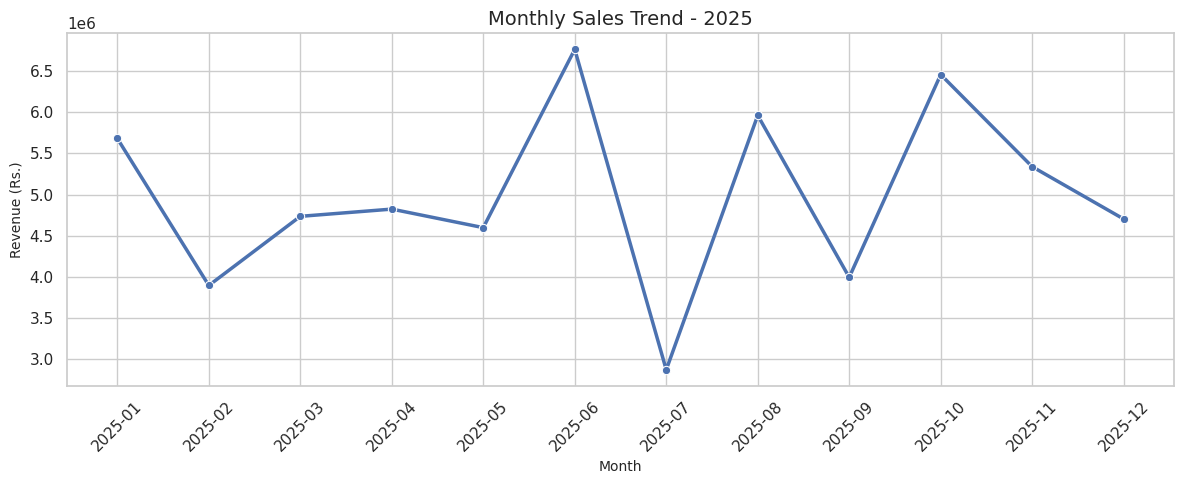

,Order_Month,Sales
0,2025-01,5681798.73
1,2025-02,3895354.60
2,2025-03,4735259.92
3,2025-04,4823280.35
4,2025-05,4598085.32
5,2025-06,6764257.05
6,2025-07,2870602.83
7,2025-08,5962010.57
8,2025-09,3994408.49
9,2025-10,6457527.41


In [6]:

monthly_sales = (
    df.groupby(
        "Order_Month",
        as_index=False
    )["Sales"]
    .sum()
)

plt.figure(
    figsize=(12, 5)
)

sns.lineplot(
    data=monthly_sales,
    x="Order_Month",
    y="Sales",
    marker="o",
    linewidth=2.5
)

plt.title(
    "Monthly Sales Trend - 2025"
)

plt.xlabel("Month")

plt.ylabel(
    "Revenue (Rs.)"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

display(
    monthly_sales
)

Category-wise Revenue

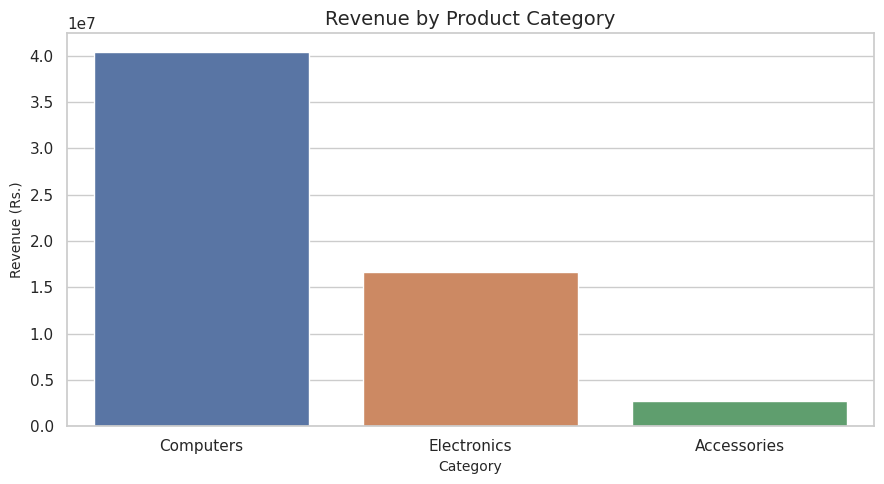

,Category,Sales
1,Computers,40384026.84
2,Electronics,16686854.99
0,Accessories,2752879.80


In [7]:

category_sales = (
    df.groupby(
        "Category",
        as_index=False
    )["Sales"]
    .sum()
    .sort_values(
        "Sales",
        ascending=False
    )
)

plt.figure(
    figsize=(9, 5)
)

sns.barplot(
    data=category_sales,
    x="Category",
    y="Sales",
    hue="Category",
    legend=False
)

plt.title(
    "Revenue by Product Category"
)

plt.xlabel("Category")

plt.ylabel(
    "Revenue (Rs.)"
)

plt.tight_layout()

plt.show()

display(
    category_sales
)

Region-wise Sales Distribution

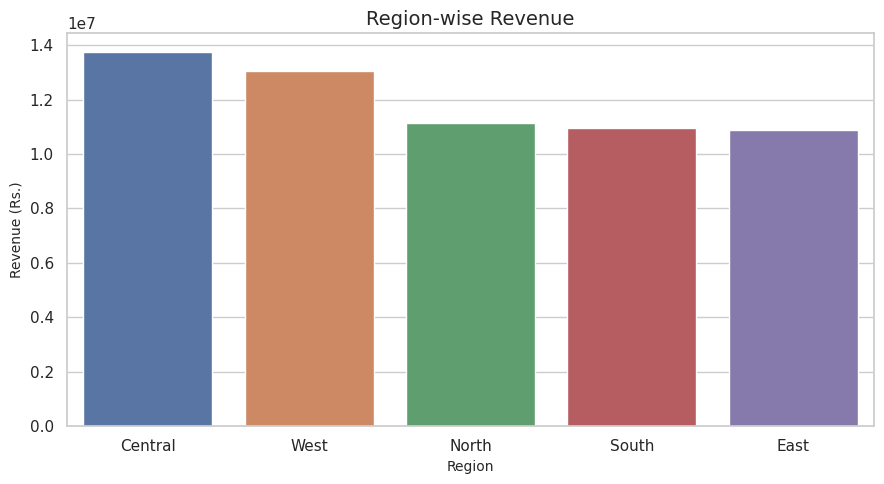

,Region,Sales
0,Central,13745333.72
4,West,13067150.69
2,North,11145587.05
3,South,10967512.41
1,East,10898177.76


In [8]:

region_sales = (
    df.groupby(
        "Region",
        as_index=False
    )["Sales"]
    .sum()
    .sort_values(
        "Sales",
        ascending=False
    )
)

plt.figure(
    figsize=(9, 5)
)

sns.barplot(
    data=region_sales,
    x="Region",
    y="Sales",
    hue="Region",
    legend=False
)

plt.title(
    "Region-wise Revenue"
)

plt.xlabel("Region")

plt.ylabel(
    "Revenue (Rs.)"
)

plt.tight_layout()

plt.show()

display(
    region_sales
)

Top 5 Products by Revenue

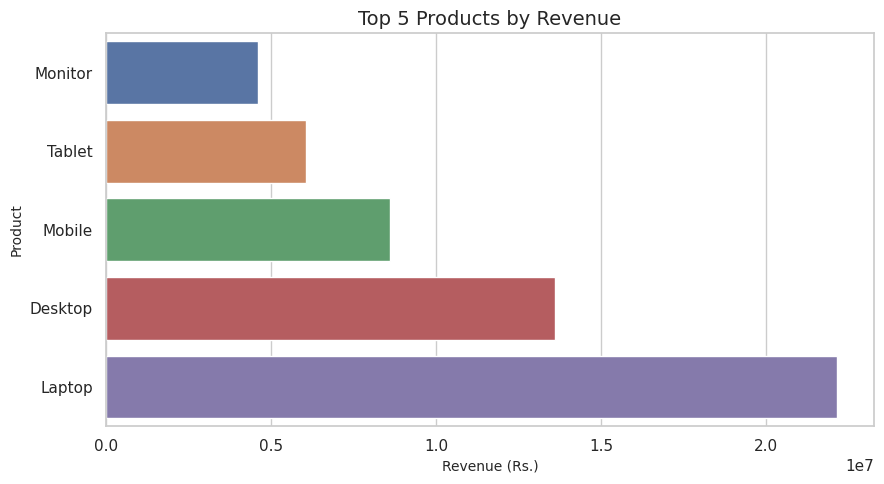

,Product,Sales
3,Laptop,22167852.57
0,Desktop,13611201.31
4,Mobile,8608234.31
8,Tablet,6048762.08
5,Monitor,4604972.96


In [9]:

top_products = (
    df.groupby(
        "Product",
        as_index=False
    )["Sales"]
    .sum()
    .sort_values(
        "Sales",
        ascending=False
    )
    .head(5)
    .sort_values(
        "Sales",
        ascending=True
    )
)

plt.figure(
    figsize=(9, 5)
)

sns.barplot(
    data=top_products,
    x="Sales",
    y="Product",
    hue="Product",
    legend=False
)

plt.title(
    "Top 5 Products by Revenue"
)

plt.xlabel(
    "Revenue (Rs.)"
)

plt.ylabel("Product")

plt.tight_layout()

plt.show()

display(
    top_products.sort_values(
        "Sales",
        ascending=False
    )
)

Sales versus Profit

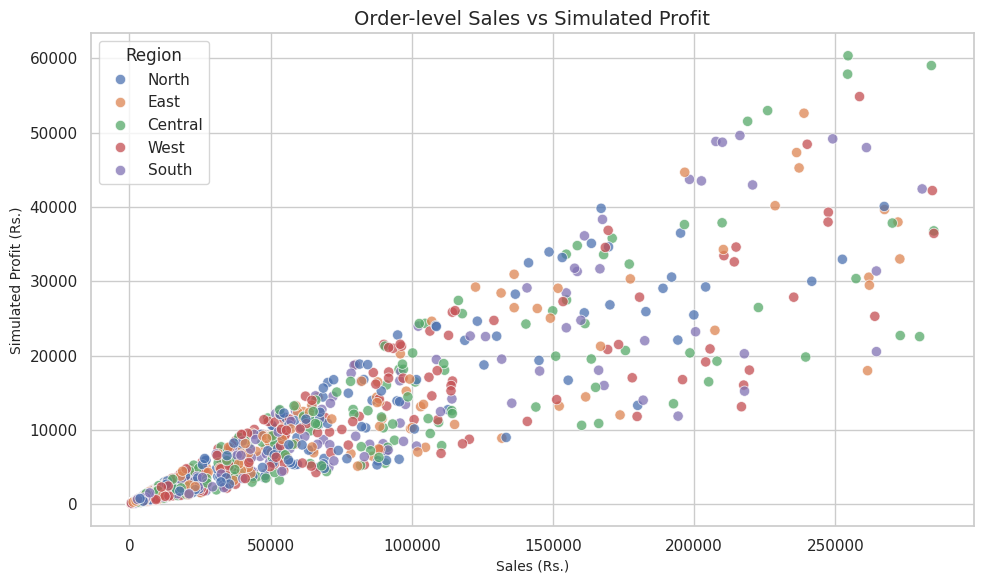

In [10]:

plt.figure(
    figsize=(10, 6)
)

sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit",
    hue="Region",
    alpha=0.75,
    s=55
)

plt.title(
    "Order-level Sales vs Simulated Profit"
)

plt.xlabel(
    "Sales (Rs.)"
)

plt.ylabel(
    "Simulated Profit (Rs.)"
)

plt.tight_layout()

plt.show()

Payment Method Analysis

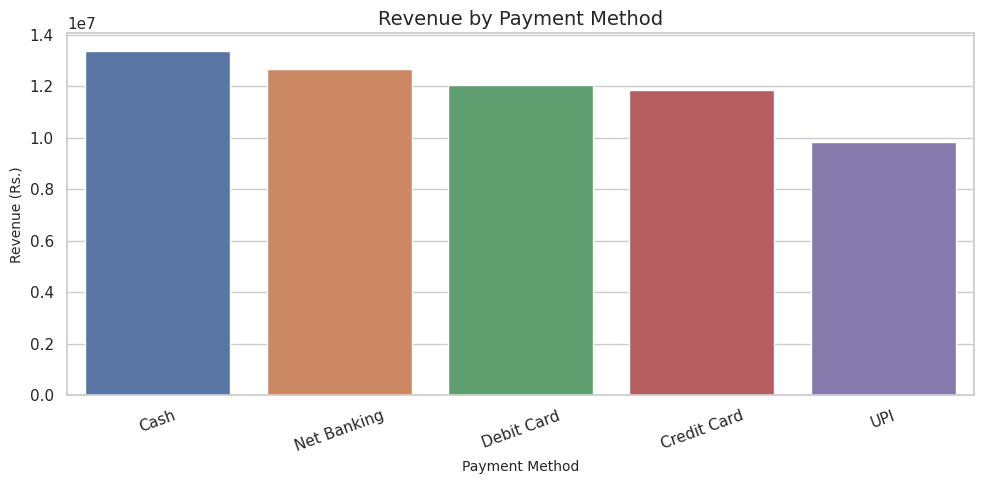

,Payment_Method,Sales
0,Cash,13394814.65
3,Net Banking,12663168.89
2,Debit Card,12074967.13
1,Credit Card,11852438.05
4,UPI,9838372.91


In [11]:

payment_sales = (
    df.groupby(
        "Payment_Method",
        as_index=False
    )["Sales"]
    .sum()
    .sort_values(
        "Sales",
        ascending=False
    )
)

plt.figure(
    figsize=(10, 5)
)

sns.barplot(
    data=payment_sales,
    x="Payment_Method",
    y="Sales",
    hue="Payment_Method",
    legend=False
)

plt.title(
    "Revenue by Payment Method"
)

plt.xlabel(
    "Payment Method"
)

plt.ylabel(
    "Revenue (Rs.)"
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()

display(
    payment_sales
)

Automatic Business Insights

In [12]:
best_product = (
    df.groupby("Product")["Sales"]
    .sum()
    .idxmax()
)

best_category = (
    df.groupby("Category")["Sales"]
    .sum()
    .idxmax()
)

best_region = (
    df.groupby("Region")["Sales"]
    .sum()
    .idxmax()
)

best_payment = (
    df.groupby("Payment_Method")["Sales"]
    .sum()
    .idxmax()
)

best_month = (
    df.groupby("Order_Month")["Sales"]
    .sum()
    .idxmax()
)

print(
    "========== BUSINESS INSIGHTS =========="
)

print(
    f"Highest-revenue product: {best_product}"
)

print(
    f"Highest-revenue category: {best_category}"
)

print(
    f"Highest-revenue region: {best_region}"
)

print(
    f"Most valuable payment method: {best_payment}"
)

print(
    f"Best sales month: {best_month}"
)

print(
    f"Total revenue: Rs. {total_sales:,.2f}"
)

print(
    f"Simulated profit: Rs. {total_profit:,.2f}"
)

print(
    "========================================"
)

========== BUSINESS INSIGHTS ==========
Highest-revenue product: Laptop
Highest-revenue category: Computers
Highest-revenue region: Central
Most valuable payment method: Cash
Best sales month: 2025-06
Total revenue: Rs. 59,823,761.63
Simulated profit: Rs. 8,972,960.95


Save and Download the Dataset

In [14]:
from google.colab import files

output_file = "sales_demo_data.csv"

df.to_csv(
    output_file,
    index=False
)

print(
    f"Saved {len(df)} rows to {output_file}"
)

files.download(
    output_file
)

Saved 1200 rows to sales_demo_data.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>